# Astronomy Application

In [5]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
manifold_type = 'S2'

## import data, visualise

Average angular variance (in rad^2):  0.030459999999999997


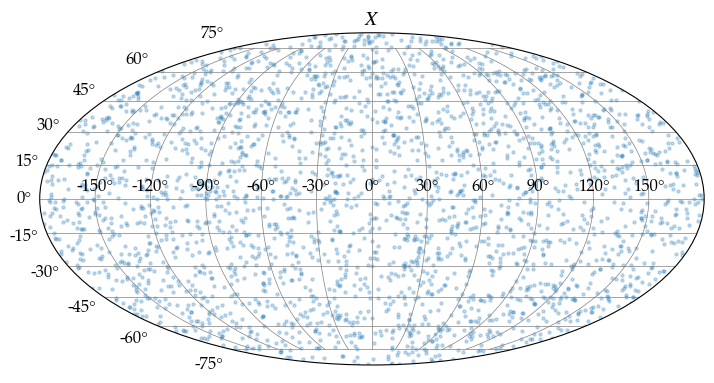

In [2]:
df = pd.read_csv('data/BATSE_4B.txt', header=None, sep='\s+', encoding='utf-8')

# Assume column 5 = RA, column 6 = Dec (in degrees)
ra = df[5].values
dec = df[6].values
phi = np.deg2rad(ra)           # longitude
theta = np.pi/2 - np.deg2rad(dec)  # colatitude
sphere = Hypersphere(dim=2)
X_sph = np.column_stack([theta, phi])
X = sphere.spherical_to_extrinsic(X_sph)

# sigma2 = np.mean(np.power(df[9].values * np.pi/180.,2))
sigma2 = 3.046*1e-2
print('Average angular variance (in rad^2): ', sigma2)

# --- plot X
fig, ax = plt.subplots(1, 1, figsize=(10, 4), subplot_kw={'projection': 'mollweide'})
S2scatter(X, ax, color='C0', alpha=0.25)  # Changed axs[0] to axs[1]
ax.set_title('$X$')
plt.tight_layout()
plt.show()

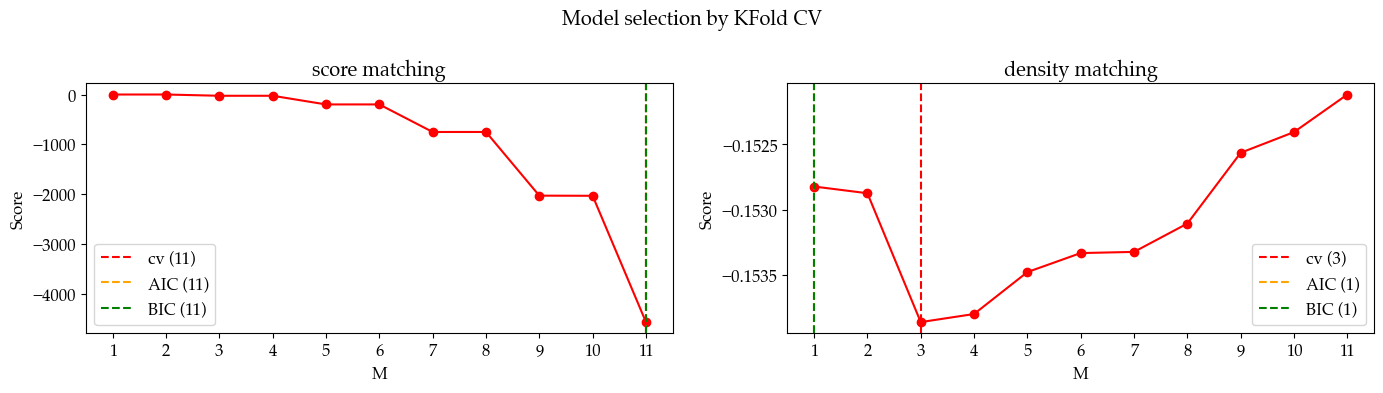

In [9]:
if True:
    M_grid = np.arange(1,12)

    selectors = [
        dict(
            title="score matching",
            func=select_M_by_scoreMatchingKFoldCV,
            kwargs=dict(
                n_splits=50,
                return_scores=True,
                random_state=None,
                rho=1e-2,
                tryearlystop=False,
            ),
            line_color="red",
        ),
        dict(
            title="density matching",
            func=select_M_by_DensityKFoldCV,
            kwargs=dict(
                n_splits=50,
                return_scores=True,
            ),
            line_color="red",
        ),
    ]

    results = []
    for s in selectors:
        Mstar, vals = s["func"](manifold_type, X, M_grid, **s["kwargs"])
        results.append((s["title"], Mstar, vals, s["line_color"]))

    if True:
        fig, axs = plt.subplots(1, len(results), figsize=(14, 4), sharex=False, sharey=False)
        fig.suptitle("Model selection by KFold CV")

        if len(results) == 1:
            axs = [axs]

        vlines = [("cv", "red"), ("AIC", "orange"), ("BIC", "green")]

        for ax, (title, Mstar, vals, line_color) in zip(axs, results):
            M_grid_ = M_grid[: len(vals)]
            ax.plot(M_grid_, vals, marker="o", color=line_color)

            for key, c in vlines:
                ax.axvline(Mstar[key], color=c, linestyle="--", label=f"{key} ({Mstar[key]})")

            ax.set_title(title)
            ax.set_xlabel("M")
            ax.set_xticks(M_grid)
            ax.set_ylabel("Score")
            ax.legend()

        plt.tight_layout()
        plt.show()

## Density estimation

In [11]:
M = Mstar['cv']
rho = 0.001


In [12]:
# Grid on S^2 (theta = colatitude, phi = longitude)
res_lat = 80
res_lon = 80
grid_theta, grid_phi = np.meshgrid(
    np.linspace(0, np.pi, res_lat),        # colatitude
    np.linspace(0, 2*np.pi, res_lon)      # longitude
)
X_grid = np.stack([
    np.sin(grid_theta) * np.cos(grid_phi),
    np.sin(grid_theta) * np.sin(grid_phi),
    np.cos(grid_theta)
], axis=-1).reshape(-1,3)


X_grid, hat_f, hat_grad_f = density_estimate('S2', X, M, X_grid)
hat_score = - hat_grad_f / (hat_f[:, np.newaxis] + rho)

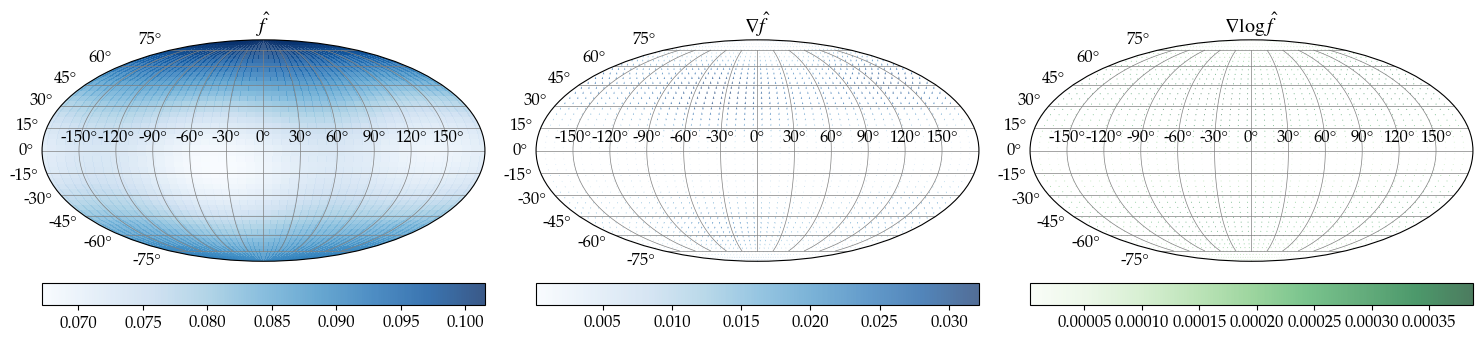

In [13]:
fig = S2plot_density_gradient_score(X,M,sigma2,rho,skip=2, mollwide=True); 
plt.show()


## Empirical Bayes denoising

In [15]:
delta = denoiser('S2', X, M, rho, sigma2, X)


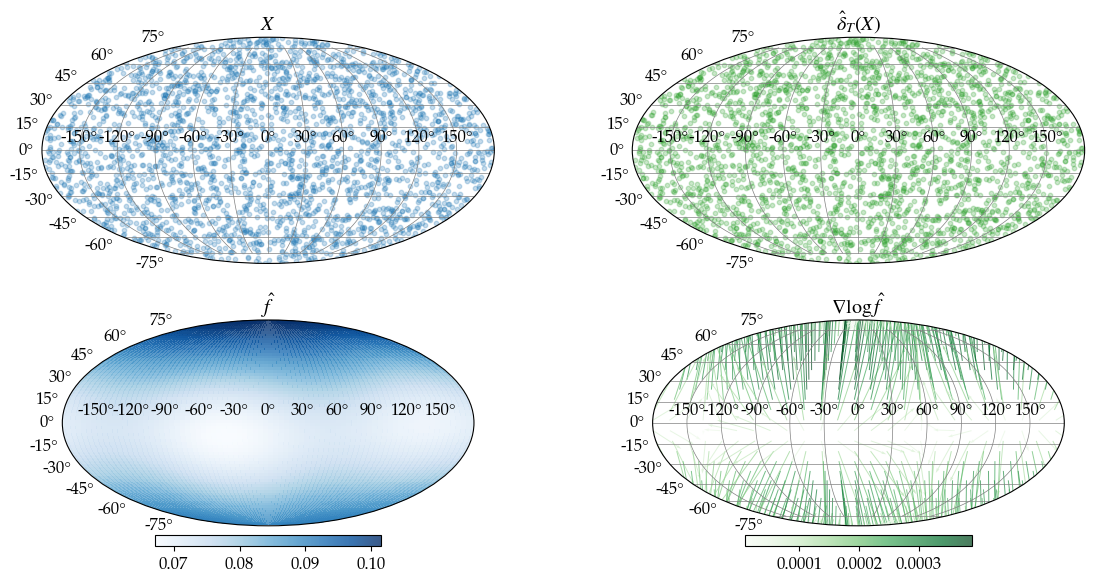

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6), 
                        subplot_kw={'projection': 'mollweide'}
                        )
grid_phi_mw = (grid_phi - np.pi)          # longitude in [-pi, pi]
grid_theta_mw = (np.pi/2 - grid_theta)    # latitude in [-pi/2, pi/2]

# Top-left plot: X
axs[0, 0].grid(True, color='gray', lw=0.5)
axs[0, 0].set_title('$X$')
S2scatter(X, ax=axs[0, 0], color='C0', alpha=0.25, s=10)

# Top-right plot: $\hat{\delta}_T(X_i)$
axs[0, 1].set_title('$\\hat{\\delta}_T(X)$')
S2scatter(delta, ax=axs[0, 1], color='C2', alpha=0.25, s=10)
# ------ SECOND ROW

# Plot estimated density --------------------------------------------------
axs[1,0].set_title(r'$\hat f$')
im_f = axs[1,0].pcolormesh(grid_phi_mw, grid_theta_mw, 
                         hat_f.reshape(res_lat, res_lon),
                         alpha=0.8,shading='auto',cmap='Blues')
fig.colorbar(im_f, ax=axs[1,0], orientation='horizontal', fraction=0.05, pad=0.04)
# Plot score --------------------------------------------------
S2plot_quiver(fig, {'X' : X, 'M' : M}, rho, 'score', axs[1,1], skip = 2, grid_resolution = 50, scale = .001)
axs[1,1].set_title(r'$\nabla \log \hat f$')
plt.tight_layout()
plt.savefig('astro.png', bbox_inches='tight')
plt.show()

